# Diffusion Policy vs. Discretized Double-DQN on Pendulum-v1

Pipeline:
1. Train a discretized Double-DQN teacher on `Pendulum-v1`.
2. Roll out the trained teacher to collect a `(state, action)` imitation dataset.
3. Train a small state-conditioned diffusion policy (student) via behavior cloning on that dataset -- no reward signal.
4. Evaluate both on return, and compare their action distributions at fixed states to show multimodal expressivity.

In [26]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt
from collections import deque

In [27]:

# Set random seeds for reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 1. Environment and action discretization

`Pendulum-v1` has a 3-dimension continuous observation `[cos(theta), sin(theta), angular_velocity]` and a 1-dimension continuous torque action in `[-2, 2]`. We discretize torque into 11 evenly spaced bins (odd count so 0 torque is representable) for the Double-DQN teacher.

In [28]:
# Create the environment and define constants
ENV_ID = "Pendulum-v1"
N_BINS = 11
ACTION_LOW, ACTION_HIGH = -2.0, 2.0
BIN_CENTERS = np.linspace(ACTION_LOW, ACTION_HIGH, N_BINS).astype(np.float32)

env = gym.make(ENV_ID)
STATE_DIM = env.observation_space.shape[0]
print(f"state_dim={STATE_DIM}, n_bins={N_BINS}, bin_centers={BIN_CENTERS}")

state_dim=3, n_bins=11, bin_centers=[-2.  -1.6 -1.2 -0.8 -0.4  0.   0.4  0.8  1.2  1.6  2. ]


## 2. Double-DQN teacher

We train a Double DQN (DDQN) teacher using separate online and target Q-networks. The trained teacher then generates state–action demonstrations for imitation learning.

In [29]:
# Create a simple feedforward neural network for the Q-function
class QNetwork(nn.Module):
    def __init__(self, state_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)

# Define an experience replay buffer to store transitions

class ReplayBuffer:
    def __init__(self, capacity):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s2, done):
        self.buf.append((s, a, r, s2, done))

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s2, done = map(np.array, zip(*batch))
        return (
            torch.tensor(s, dtype=torch.float32, device=device),
            torch.tensor(a, dtype=torch.int64, device=device),
            torch.tensor(r, dtype=torch.float32, device=device),
            torch.tensor(s2, dtype=torch.float32, device=device),
            torch.tensor(done, dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buf)

In [30]:
# Define hyperparameters and initialize networks, optimizer, and replay buffer
GAMMA = 0.99
LR = 1e-3
BATCH_SIZE = 128
BUFFER_CAPACITY = 50_000
TARGET_SYNC_EVERY = 500
EPS_START, EPS_END, EPS_DECAY_STEPS = 1.0, 0.05, 20_000
N_EPISODES_TEACHER = 400
EARLY_STOP_WINDOW = 25
EARLY_STOP_RETURN = -200.0  # Higher (closer to zero) is better.
EARLY_STOP_PATIENCE = 10
MIN_TEACHER_EPISODES = 100

# Initialize the online and target Q-networks, optimizer, and replay buffer
online_net = QNetwork(STATE_DIM, N_BINS).to(device)
target_net = QNetwork(STATE_DIM, N_BINS).to(device)
target_net.load_state_dict(online_net.state_dict())
optimizer = torch.optim.Adam(online_net.parameters(), lr=LR)
buffer = ReplayBuffer(BUFFER_CAPACITY)

# Run the teacher agent to populate the replay buffer with transitions for imitation learning
def eps_by_step(step):
    frac = min(1.0, step / EPS_DECAY_STEPS)
    return EPS_START + frac * (EPS_END - EPS_START)


# Define the action selection function for the teacher agent (epsilon-greedy policy)
def select_action(state, step, greedy=False):
    if not greedy and random.random() < eps_by_step(step):
        return random.randrange(N_BINS)
    with torch.no_grad():
        s = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        return int(online_net(s).argmax(dim=1).item())

# Define the training step function for the online Q-network
def train_step():
    if len(buffer) < BATCH_SIZE:
        return None
    s, a, r, s2, done = buffer.sample(BATCH_SIZE)
    q_sa = online_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        next_actions = online_net(s2).argmax(dim=1, keepdim=True)
        next_q = target_net(s2).gather(1, next_actions).squeeze(1)
        target = r + GAMMA * (1.0 - done) * next_q
    loss = F.smooth_l1_loss(q_sa, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

In [31]:
# Run the teacher agent to populate the replay buffer with transitions for imitation learning
global_step = 0
episode_returns = []
best_recent_return = -np.inf
best_teacher_state = None
early_stop_streak = 0

for ep in range(N_EPISODES_TEACHER):
    state, _ = env.reset(seed=SEED + ep)
    ep_return = 0.0
    done = False
    while not done:
        action_idx = select_action(state, global_step)
        # Convert the discrete action index to a continuous torque value using the bin centers
        torque = np.array([BIN_CENTERS[action_idx]], dtype=np.float32)
        next_state, reward, terminated, truncated, _ = env.step(torque)
        done = terminated or truncated
        buffer.push(state, action_idx, reward, next_state, float(done))
        state = next_state
        ep_return += reward
        global_step += 1

        train_step()
        if global_step % TARGET_SYNC_EVERY == 0:
            target_net.load_state_dict(online_net.state_dict())

    episode_returns.append(ep_return)
    if len(episode_returns) >= EARLY_STOP_WINDOW:
        recent = np.mean(episode_returns[-EARLY_STOP_WINDOW:])
        if recent > best_recent_return:
            best_recent_return = recent
            best_teacher_state = {
                name: value.detach().clone()
                for name, value in online_net.state_dict().items()
            }

        if ep + 1 >= MIN_TEACHER_EPISODES and recent >= EARLY_STOP_RETURN:
            early_stop_streak += 1
        else:
            early_stop_streak = 0

        if early_stop_streak >= EARLY_STOP_PATIENCE:
            print(
                f"early stopping at episode {ep + 1}: "
                f"{EARLY_STOP_WINDOW}-episode average={recent:.1f}"
            )
            break

    if (ep + 1) % 25 == 0:
        recent = np.mean(episode_returns[-EARLY_STOP_WINDOW:])
        print(f"episode {ep+1}/{N_EPISODES_TEACHER}  return={ep_return:.1f}  "
              f"avg_last25={recent:.1f}  eps={eps_by_step(global_step):.3f}")

if best_teacher_state is not None:
    online_net.load_state_dict(best_teacher_state)
    target_net.load_state_dict(best_teacher_state)
    print(f"restored best teacher: {EARLY_STOP_WINDOW}-episode average={best_recent_return:.1f}")

episode 25/400  return=-1068.7  avg_last25=-1237.1  eps=0.762
episode 50/400  return=-497.6  avg_last25=-729.0  eps=0.525
episode 75/400  return=-483.9  avg_last25=-441.4  eps=0.288
episode 100/400  return=-6.4  avg_last25=-269.7  eps=0.050
episode 125/400  return=-231.8  avg_last25=-269.1  eps=0.050
episode 150/400  return=-235.0  avg_last25=-291.9  eps=0.050
episode 175/400  return=-227.6  avg_last25=-203.6  eps=0.050
early stopping at episode 187: 25-episode average=-197.2
restored best teacher: 25-episode average=-183.5


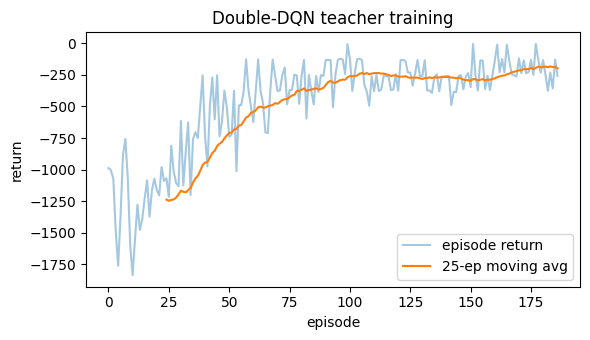

In [32]:
plt.figure(figsize=(6, 3.5))
plt.plot(episode_returns, alpha=0.4, label="episode return")
window = 25
if len(episode_returns) >= window:
    smoothed = np.convolve(episode_returns, np.ones(window) / window, mode="valid")
    plt.plot(range(window - 1, len(episode_returns)), smoothed, label=f"{window}-ep moving avg")
plt.xlabel("episode")
plt.ylabel("return")
plt.title("Double-DQN teacher training")
plt.legend()
plt.tight_layout()
plt.show()

### 2.1 Visualize the trained teacher

Render one greedy evaluation episode to inspect whether the Double-DQN teacher swings up and balances the pendulum.

In [33]:
from matplotlib import animation
from IPython.display import HTML

render_env = gym.make(ENV_ID, render_mode="rgb_array")
state, _ = render_env.reset(seed=20_000)
teacher_frames = []
done = False

while not done:
    teacher_frames.append(np.array(render_env.render(), copy=True))
    action_idx = select_action(state, step=0, greedy=True)
    torque = np.array([BIN_CENTERS[action_idx]], dtype=np.float32)
    state, _, terminated, truncated, _ = render_env.step(torque)
    done = terminated or truncated

render_env.close()

fig, ax = plt.subplots(figsize=(4, 4))
frame_image = ax.imshow(teacher_frames[0])
ax.axis("off")
ax.set_title("Greedy Double-DQN teacher")

def update_teacher_frame(frame_index):
    frame_image.set_data(teacher_frames[frame_index])
    return (frame_image,)

teacher_animation = animation.FuncAnimation(
    fig, update_teacher_frame, frames=len(teacher_frames), interval=50, blit=True
)
plt.close(fig)
HTML(teacher_animation.to_jshtml())

## 3. Collect imitation dataset from the trained teacher

Roll the greedy teacher out (no exploration noise) and log `(state, torque)` pairs, using the bin center as the continuous action target for the student.

In [34]:
N_ROLLOUT_EPISODES = 75

states_list = []
actions_list = []

for ep in range(N_ROLLOUT_EPISODES):
    state, _ = env.reset(seed=10_000 + ep)
    done = False
    while not done:
        action_idx = select_action(state, global_step, greedy=True)
        torque = BIN_CENTERS[action_idx]
        states_list.append(state.copy())
        actions_list.append([torque])
        next_state, _, terminated, truncated, _ = env.step(np.array([torque], dtype=np.float32))
        done = terminated or truncated
        state = next_state

demo_states = np.array(states_list, dtype=np.float32)
demo_actions = np.array(actions_list, dtype=np.float32)
print(f"collected {len(demo_states)} transitions from {N_ROLLOUT_EPISODES} teacher episodes")

collected 15000 transitions from 75 teacher episodes


## 4. Diffusion policy student

A small state-conditioned DDPM. It takes a state and a noisy action and predicts the noise added to that single continuous torque value. Training regresses this noise prediction against the teacher's demonstration actions, purely behavior cloning, no reward involved.

In [35]:
T_DIFFUSION = 30

betas = torch.linspace(1e-4, 2e-2, T_DIFFUSION, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)


def sinusoidal_embedding(t, dim=16):
    half = dim // 2
    freqs = torch.exp(-np.log(10000) * torch.arange(half, device=device).float() / half)
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
    return torch.cat([torch.sin(args), torch.cos(args)], dim=1)


class DiffusionPolicy(nn.Module):
    def __init__(self, state_dim, action_dim=1, time_dim=16, hidden=128):
        super().__init__()
        self.time_dim = time_dim
        self.net = nn.Sequential(
            nn.Linear(action_dim + time_dim + state_dim, hidden), nn.Mish(),
            nn.Linear(hidden, hidden), nn.Mish(),
            nn.Linear(hidden, action_dim),
        )

    def forward(self, noisy_action, t, state):
        t_emb = sinusoidal_embedding(t, self.time_dim)
        x = torch.cat([noisy_action, t_emb, state], dim=1)
        return self.net(x)


diffusion_policy = DiffusionPolicy(STATE_DIM).to(device)
diffusion_optimizer = torch.optim.Adam(diffusion_policy.parameters(), lr=1e-3)

In [36]:
demo_states_t = torch.tensor(demo_states, device=device)
demo_actions_t = torch.tensor(demo_actions, device=device)

N_STUDENT_STEPS = 5000
BC_BATCH_SIZE = 256
n_demo = demo_states_t.shape[0]

for step in range(1, N_STUDENT_STEPS + 1):
    idx = torch.randint(0, n_demo, (BC_BATCH_SIZE,), device=device)
    s_batch = demo_states_t[idx]
    a0_batch = demo_actions_t[idx]

    t_batch = torch.randint(0, T_DIFFUSION, (BC_BATCH_SIZE,), device=device)
    noise = torch.randn_like(a0_batch)
    ab = alpha_bars[t_batch].unsqueeze(1)
    noisy_action = torch.sqrt(ab) * a0_batch + torch.sqrt(1 - ab) * noise

    pred_noise = diffusion_policy(noisy_action, t_batch, s_batch)
    loss = F.mse_loss(pred_noise, noise)

    diffusion_optimizer.zero_grad()
    loss.backward()
    diffusion_optimizer.step()

    if step % 500 == 0:
        print(f"step {step}/{N_STUDENT_STEPS}  bc_loss={loss.item():.4f}")

step 500/5000  bc_loss=0.4693
step 1000/5000  bc_loss=0.3425
step 1500/5000  bc_loss=0.1903
step 2000/5000  bc_loss=0.1399
step 2500/5000  bc_loss=0.2106
step 3000/5000  bc_loss=0.1602
step 3500/5000  bc_loss=0.1715
step 4000/5000  bc_loss=0.0898
step 4500/5000  bc_loss=0.1640
step 5000/5000  bc_loss=0.1314


In [37]:
@torch.no_grad()
def sample_actions(states_batch, n_samples=1):
    """states_batch: (B, state_dim) tensor. Returns (n_samples, B, 1) sampled torques."""
    B = states_batch.shape[0]
    s_rep = states_batch.unsqueeze(0).repeat(n_samples, 1, 1).reshape(n_samples * B, -1)
    x = torch.randn(n_samples * B, 1, device=device)

    for t in reversed(range(T_DIFFUSION)):
        t_batch = torch.full((n_samples * B,), t, device=device, dtype=torch.long)
        pred_noise = diffusion_policy(x, t_batch, s_rep)
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]
        beta_t = betas[t]

        mean = (1 / torch.sqrt(alpha_t)) * (x - (beta_t / torch.sqrt(1 - alpha_bar_t)) * pred_noise)
        if t > 0:
            x = mean + torch.sqrt(beta_t) * torch.randn_like(x)
        else:
            x = mean

    x = x.clamp(ACTION_LOW, ACTION_HIGH)
    return x.reshape(n_samples, B, 1)

### 4.1 Policy-comparison rendering helper

Define the episode renderer after both the teacher action selector and diffusion action sampler are available.

In [38]:
COMPARISON_SEED = 20_000

def render_policy_episode(policy_name, seed):
    comparison_env = gym.make(ENV_ID, render_mode="rgb_array")
    state, _ = comparison_env.reset(seed=seed)
    frames = []
    episode_return = 0.0
    done = False

    while not done:
        frames.append(np.array(comparison_env.render(), copy=True))
        if policy_name == "teacher":
            action_idx = select_action(state, step=0, greedy=True)
            action = np.array([BIN_CENTERS[action_idx]], dtype=np.float32)
        elif policy_name == "student":
            state_tensor = torch.tensor(
                state, dtype=torch.float32, device=device
            ).unsqueeze(0)
            action = sample_actions(state_tensor, n_samples=1)[0, 0].cpu().numpy()
        else:
            raise ValueError(f"Unknown policy: {policy_name}")

        state, reward, terminated, truncated, _ = comparison_env.step(action)
        episode_return += reward
        done = terminated or truncated

    comparison_env.close()
    return frames, episode_return

## 5. Evaluation: return comparison

Run the greedy teacher and the diffusion student (single sample per step) on the same set of eval episodes/seeds.

In [39]:
N_EVAL_EPISODES = 20


def eval_teacher(n_episodes):
    returns = []
    for ep in range(n_episodes):
        state, _ = env.reset(seed=20_000 + ep)
        done = False
        ep_return = 0.0
        while not done:
            action_idx = select_action(state, global_step, greedy=True)
            torque = np.array([BIN_CENTERS[action_idx]], dtype=np.float32)
            state, reward, terminated, truncated, _ = env.step(torque)
            done = terminated or truncated
            ep_return += reward
        returns.append(ep_return)
    return np.array(returns)


def eval_student(n_episodes):
    returns = []
    for ep in range(n_episodes):
        state, _ = env.reset(seed=20_000 + ep)
        done = False
        ep_return = 0.0
        while not done:
            s_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            torque = sample_actions(s_t, n_samples=1)[0, 0].cpu().numpy()
            state, reward, terminated, truncated, _ = env.step(torque)
            done = terminated or truncated
            ep_return += reward
        returns.append(ep_return)
    return np.array(returns)


teacher_returns = eval_teacher(N_EVAL_EPISODES)
student_returns = eval_student(N_EVAL_EPISODES)

print(f"Teacher (discretized Double-DQN): mean={teacher_returns.mean():.1f} std={teacher_returns.std():.1f}")
print(f"Student (diffusion policy, BC):   mean={student_returns.mean():.1f} std={student_returns.std():.1f}")

Teacher (discretized Double-DQN): mean=-137.2 std=65.3
Student (diffusion policy, BC):   mean=-1017.6 std=171.0


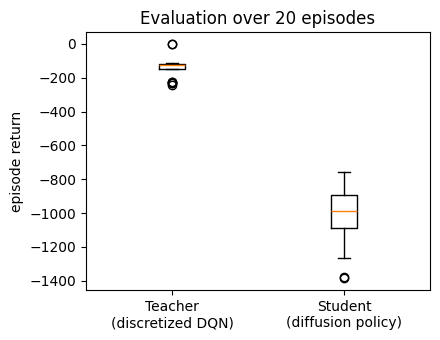

In [40]:
plt.figure(figsize=(4.5, 3.5))
plt.boxplot([teacher_returns, student_returns], tick_labels=["Teacher\n(discretized DQN)", "Student\n(diffusion policy)"])
plt.ylabel("episode return")
plt.title(f"Evaluation over {N_EVAL_EPISODES} episodes")
plt.tight_layout()
plt.show()

### 5.1 Teacher versus advanced-policy visualization

Compare the discretized Double-DQN teacher and advanced diffusion-policy student side by side from the same initial state. The displayed returns quantify performance during the animated episode.

In [41]:
teacher_comparison_frames, teacher_comparison_return = render_policy_episode(
    "teacher", COMPARISON_SEED
)
torch.manual_seed(SEED)
student_comparison_frames, student_comparison_return = render_policy_episode(
    "student", COMPARISON_SEED
)

comparison_frame_count = min(
    len(teacher_comparison_frames), len(student_comparison_frames)
)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
teacher_image = axes[0].imshow(teacher_comparison_frames[0])
student_image = axes[1].imshow(student_comparison_frames[0])
axes[0].set_title(f"Teacher: Double DQN\nreturn={teacher_comparison_return:.1f}")
axes[1].set_title(f"Advanced: diffusion policy\nreturn={student_comparison_return:.1f}")
for axis in axes:
    axis.axis("off")
fig.tight_layout()

def update_comparison_frame(frame_index):
    teacher_image.set_data(teacher_comparison_frames[frame_index])
    student_image.set_data(student_comparison_frames[frame_index])
    return teacher_image, student_image

policy_comparison_animation = animation.FuncAnimation(
    fig,
    update_comparison_frame,
    frames=comparison_frame_count,
    interval=50,
    blit=True,
)
plt.close(fig)
HTML(policy_comparison_animation.to_jshtml())

### 5.2 Double-DQN balance and torque diagnostic

Inspect the teacher's commanded torque separately from its visible rotation. A pendulum can continue rotating clockwise while negative torque is braking it. Successful balancing is indicated by an angle and angular velocity that settle near zero.

positive-torque steps: 157
negative-torque steps: 43
zero-torque steps:     0
near-upright, low-speed steps: 95.5%


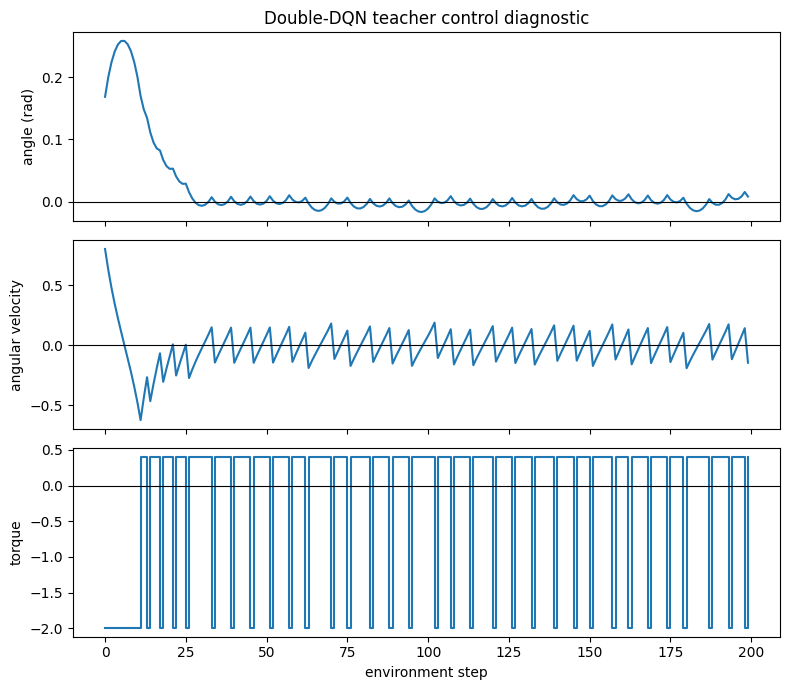

In [42]:
diagnostic_env = gym.make(ENV_ID)
state, _ = diagnostic_env.reset(seed=COMPARISON_SEED)
teacher_angles = []
teacher_angular_velocities = []
teacher_torques = []
done = False

while not done:
    teacher_angles.append(np.arctan2(state[1], state[0]))
    teacher_angular_velocities.append(state[2])
    action_idx = select_action(state, step=0, greedy=True)
    torque = float(BIN_CENTERS[action_idx])
    teacher_torques.append(torque)
    state, _, terminated, truncated, _ = diagnostic_env.step(
        np.array([torque], dtype=np.float32)
    )
    done = terminated or truncated

diagnostic_env.close()
teacher_angles = np.asarray(teacher_angles)
teacher_angular_velocities = np.asarray(teacher_angular_velocities)
teacher_torques = np.asarray(teacher_torques)

positive_steps = int(np.sum(teacher_torques > 1e-6))
negative_steps = int(np.sum(teacher_torques < -1e-6))
zero_steps = int(np.sum(np.abs(teacher_torques) <= 1e-6))
balanced = (np.abs(teacher_angles) < 0.2) & (
    np.abs(teacher_angular_velocities) < 1.0
)
print(f"positive-torque steps: {positive_steps}")
print(f"negative-torque steps: {negative_steps}")
print(f"zero-torque steps:     {zero_steps}")
print(f"near-upright, low-speed steps: {balanced.mean():.1%}")

fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
axes[0].plot(teacher_angles)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("angle (rad)")
axes[0].set_title("Double-DQN teacher control diagnostic")
axes[1].plot(teacher_angular_velocities)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("angular velocity")
axes[2].step(range(len(teacher_torques)), teacher_torques, where="post")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_ylabel("torque")
axes[2].set_xlabel("environment step")
fig.tight_layout()
plt.show()

## 6. Action-distribution comparison at fixed states

Pick a few representative states (near-vertical/balanced, near-horizontal, mid-swing) and compare:
- the teacher's implied action: a single greedy bin choice (plus the full Q-value profile over bins), and
- the student's sampled action distribution: many diffusion samples at that state, shown as a histogram.

This is the qualitative evidence for multimodal expressivity referenced in Related Works.

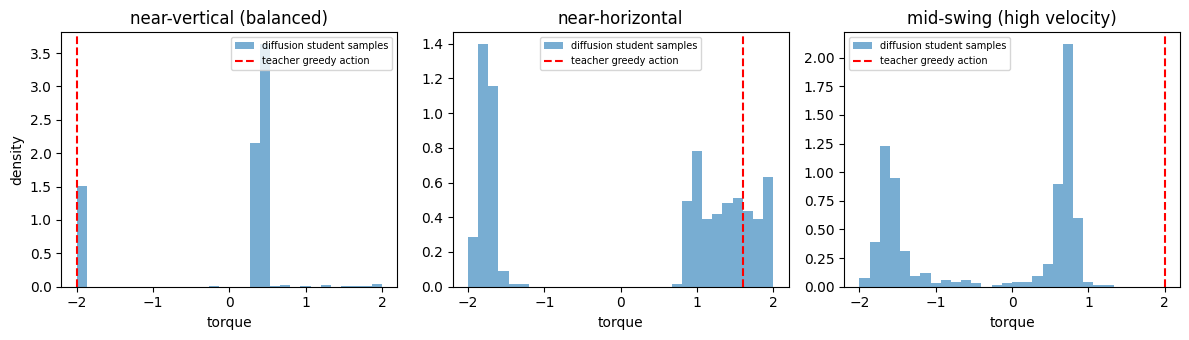

In [43]:
def angle_state(theta, theta_dot):
    return np.array([np.cos(theta), np.sin(theta), theta_dot], dtype=np.float32)


fixed_states = {
    "near-vertical (balanced)": angle_state(0.05, 0.0),
    "near-horizontal": angle_state(np.pi / 2, 0.0),
    "mid-swing (high velocity)": angle_state(np.pi / 4, 4.0),
}

N_SAMPLES_PER_STATE = 500

fig, axes = plt.subplots(1, len(fixed_states), figsize=(4 * len(fixed_states), 3.5), sharey=False)

for ax, (label, s) in zip(axes, fixed_states.items()):
    s_t = torch.tensor(s, device=device).unsqueeze(0)

    with torch.no_grad():
        q_values = online_net(s_t).cpu().numpy().flatten()
    greedy_torque = BIN_CENTERS[int(np.argmax(q_values))]

    samples = sample_actions(s_t, n_samples=N_SAMPLES_PER_STATE)[:, 0, 0].cpu().numpy()

    ax.hist(samples, bins=30, range=(ACTION_LOW, ACTION_HIGH), density=True,
            alpha=0.6, label="diffusion student samples")
    ax.axvline(greedy_torque, color="red", linestyle="--", label="teacher greedy action")
    ax.set_title(label)
    ax.set_xlabel("torque")
    ax.legend(fontsize=7)

axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

## 7. Summary table (for `tab:setup` / results in main.tex)

In [44]:
summary = {
    "env": ENV_ID,
    "n_bins (teacher)": N_BINS,
    "diffusion steps (student)": T_DIFFUSION,
    "teacher train episodes": N_EPISODES_TEACHER,
    "imitation rollout episodes": N_ROLLOUT_EPISODES,
    "imitation transitions": len(demo_states),
    "student BC steps": N_STUDENT_STEPS,
    "eval episodes": N_EVAL_EPISODES,
    "teacher return (mean +/- std)": f"{teacher_returns.mean():.1f} +/- {teacher_returns.std():.1f}",
    "student return (mean +/- std)": f"{student_returns.mean():.1f} +/- {student_returns.std():.1f}",
}
for k, v in summary.items():
    print(f"{k}: {v}")

env: Pendulum-v1
n_bins (teacher): 11
diffusion steps (student): 30
teacher train episodes: 400
imitation rollout episodes: 75
imitation transitions: 15000
student BC steps: 5000
eval episodes: 20
teacher return (mean +/- std): -137.2 +/- 65.3
student return (mean +/- std): -1017.6 +/- 171.0
